In [1]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("pip install -q git+https://github.com/PritRaj1/tensor_inv.git")
else:
    src = "src" if os.path.isdir("src") else "../src"
    sys.path.insert(0, src)

In [2]:
import torch
import matplotlib.pyplot as plt
from torch.utils.benchmark import Compare, Timer

from tensor_inv import cholesky, crt_matmul, lu, rsvd

assert torch.cuda.is_available(), "need GPU"
print(f"GPU: {torch.cuda.get_device_name()}")
print(f"CUDA: {torch.version.cuda}")
print(f"capability: {torch.cuda.get_device_capability()}")

plt.rcParams["figure.dpi"] = 120

GPU: NVIDIA GeForce GTX 1650
CUDA: 13.0
capability: (7, 5)


In [3]:
SIZES = [64, 128, 256, 512, 1024]
DEVICE = "cuda"
DTYPE = torch.float64


def timers_for(label, stmt_ref, stmt_crt, setup, crt_fn):
    ts = []
    shared = {"torch": torch, "dtype": DTYPE, "device": DEVICE}
    for n in SIZES:
        s = setup.format(n=n)
        ts.append(
            Timer(
                stmt_ref,
                s,
                globals=shared,
                label=label,
                sub_label=f"n={n}",
                description="torch",
            )
        )
        ts.append(
            Timer(
                stmt_crt,
                s,
                globals={**shared, "fn": crt_fn},
                label=label,
                sub_label=f"n={n}",
                description="CRT",
            )
        )
    return ts

In [4]:
timers = []

timers += timers_for(
    "matmul",
    "A @ B",
    "fn(A, B)",
    "A = torch.randn({n},{n},dtype=dtype,device=device); B = torch.randn({n},{n},dtype=dtype,device=device)",
    crt_matmul,
)

timers += timers_for(
    "cholesky",
    "torch.linalg.cholesky(A)",
    "fn(A)",
    "M = torch.randn({n},{n},dtype=dtype,device=device); A = M @ M.T + {n}*torch.eye({n},dtype=dtype,device=device)",
    cholesky,
)

timers += timers_for(
    "lu",
    "torch.linalg.lu(A)",
    "fn(A)",
    "A = torch.randn({n},{n},dtype=dtype,device=device)",
    lu,
)

timers += timers_for(
    "svd",
    "torch.linalg.svd(A, full_matrices=False)",
    "fn(A, rank=20)",
    "A = torch.randn({n},{n},dtype=dtype,device=device)",
    rsvd,
)

/home/pritmanguy/Work/tensor_inv/notebooks/../src/tensor_inv/crt_matmul.py:113: UserWarning: cublasLt int8 GEMM not supported on this GPU (no tensor cores?). Falling back to FP32 bmm.
  residues = _matmul_residues(a_res, b_res, moduli)


[------------- matmul -------------]
              |   torch   |    CRT  
1 threads: -------------------------
      n=64    |     76.7  |    849.3
      n=128   |     81.7  |    974.5
      n=256   |    362.5  |   2852.1
      n=512   |   2497.2  |  13322.3
      n=1024  |  21113.0  |  70207.0

Times are in microseconds (us).

[------------ cholesky ------------]
              |  torch   |    CRT   
1 threads: -------------------------
      n=64    |   122.4  |     163.1
      n=128   |   222.0  |    1644.3
      n=256   |   471.1  |    4046.6
      n=512   |  1604.6  |   18466.8
      n=1024  |  5783.3  |  103414.5

Times are in microseconds (us).

[---------------- lu ---------------]
              |   torch   |    CRT   
1 threads: --------------------------
      n=64    |    154.4  |   22218.5
      n=128   |    268.7  |   45855.2
      n=256   |    859.0  |   94305.0
      n=512   |   4671.2  |  195627.7
      n=1024  |  15012.7  |  471003.7

Times are in microseconds (us).

[-

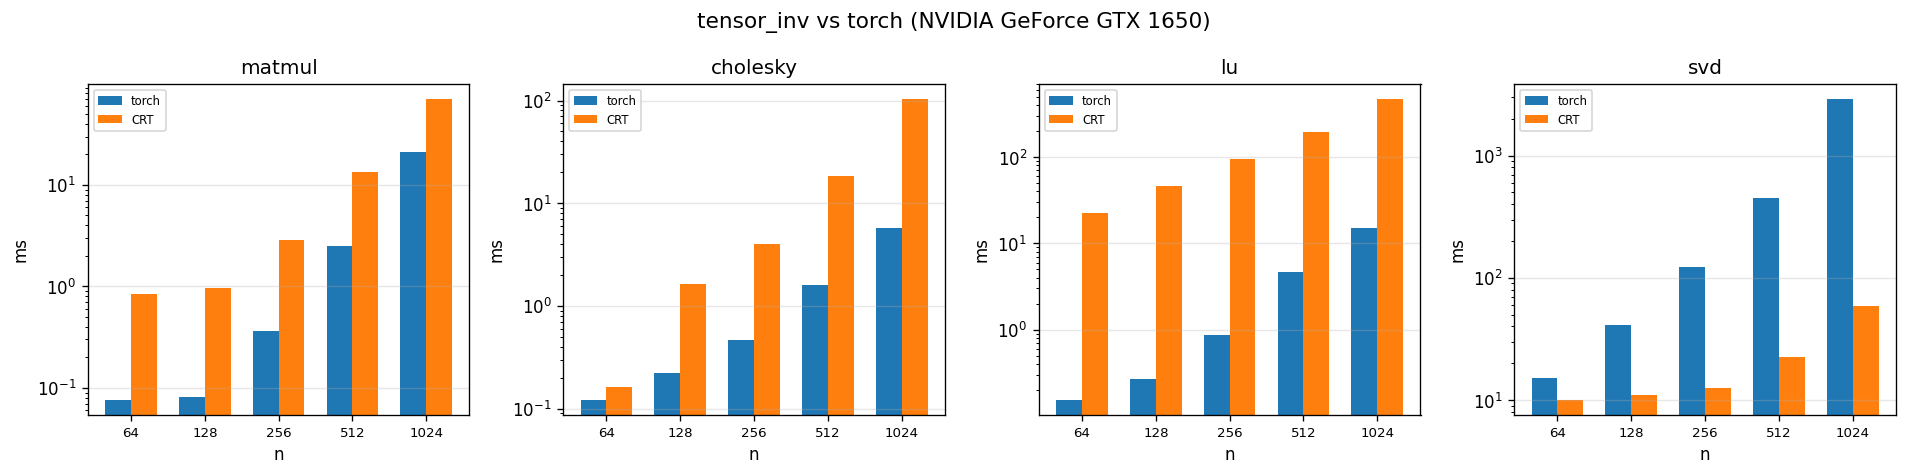

In [5]:
results = [t.blocked_autorange(min_run_time=1.0) for t in timers]
Compare(results).print()

labels = ["matmul", "cholesky", "lu", "svd"]
by_label = {name: {"torch": [], "CRT": []} for name in labels}
for r in results:
    desc = "CRT" if "CRT" in r.description else "torch"
    by_label[r.label][desc].append(r.median * 1e3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f"tensor_inv vs torch ({torch.cuda.get_device_name()})", fontsize=13)

w = 0.35
for ax, label in zip(axes, labels):
    t_ref = by_label[label]["torch"]
    t_crt = by_label[label]["CRT"]
    x = range(len(SIZES))
    ax.bar([i - w / 2 for i in x], t_ref, w, label="torch")
    ax.bar([i + w / 2 for i in x], t_crt, w, label="CRT")
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(n) for n in SIZES], fontsize=8)
    ax.set_xlabel("n")
    ax.set_ylabel("ms")
    ax.set_yscale("log")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()